# Сначала подготовим единый датасет

In [ ]:
import os
import json
import pandas as pd
from collections import defaultdict



def load_epicrisis_data(folder_path):
    """Загружает все эпикризы из папки в единый датафрейм"""
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                epicrisis = json.load(f)
                
                # Собираем все текстовые части
                text_parts = []
                
                # Жалобы
                if epicrisis.get('complaints') and epicrisis['complaints'].get('processed_text'):
                    text_parts.append(epicrisis['complaints']['processed_text'])
                
                # Анамнез заболевания
                if epicrisis.get('disease_history') and epicrisis['disease_history'].get('processed_text'):
                    text_parts.append(epicrisis['disease_history']['processed_text'])
                
                # Физикальное обследование
                if epicrisis.get('physical_examination') and epicrisis['physical_examination'].get('processed_text'):
                    text_parts.append(epicrisis['physical_examination']['processed_text'])
                
                # Собираем числовые параметры
                numeric_params = {}
                if epicrisis.get('numeric_parameters'):
                    for param_name, param_data in epicrisis['numeric_parameters'].items():
                        numeric_params[param_name] = param_data.get('value')
                
                # Целевой текст - объединяем все части
                target_text = ' '.join(text_parts)
                
                data.append({
                    'file_id': filename,
                    'diagnosis': epicrisis.get('diagnosis', {}).get('display_name', ''),
                    'diagnosis_code': epicrisis.get('diagnosis', {}).get('diagnosis_text', ''),
                    'complaints': epicrisis.get('complaints', {}).get('processed_text', ''),
                    'disease_history': epicrisis.get('disease_history', {}).get('processed_text', ''),
                    'physical_examination': epicrisis.get('physical_examination', {}).get('processed_text', ''),
                    'target_text': target_text,
                    'numeric_parameters': numeric_params,
                    'text_length': len(target_text)
                })
    
    return pd.DataFrame(data)

# Загрузка данных
folder_path = r"C:\Users\ckopn\Desktop\epikriz\Epikriz_project\epi_rash\preprocessed_medical_results"
df = load_epicrisis_data(folder_path)

# Анализ
print(f"Загружено {len(df)} эпикризов")
print(f"Средняя длина текста: {df['text_length'].mean():.0f} символов")
print(f"Диагнозы: {df['diagnosis'].value_counts().head()}")

Загружено 2013 эпикризов
Средняя длина текста: 1571 символов
Диагнозы: diagnosis
Другая уточненная хроническая обструктивная легочная болезнь                                      167
Злокачественное новообразование верхней доли, бронхов или легкого                                 141
Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры    138
Злокачественное новообразование нижней доли, бронхов или легкого                                  113
COVID-19, вирус идентифицирован                                                                    88
Name: count, dtype: int64


# Подготовка данных для CatBoost

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import json
import os


def prepare_catboost_features(df):
    """Подготовка признаков для CatBoost"""
    
    features_list = []
    
    for idx, row in df.iterrows():
        features = {}
        
        # 1. Числовые параметры (основные витальные признаки)
        numeric_params = row['numeric_parameters']
        vital_signs = [
            'Температура тела', 'Артериальное давление систолическое',
            'Артериальное давление диастолическое', 'Частота сердечных сокращений',
            'Пульс', 'Сатурация', 'Частота дыхания'
        ]
        
        for sign in vital_signs:
            features[f'num_{sign}'] = numeric_params.get(sign, 0) or 0
        
        # 2. Лабораторные показатели
        lab_tests = [
            'Гематокрит крови методом автоматизированного подсчёта',
            'Лейкоциты, количество в крови методом автоматизированного подсчёта',
            'Нейтрофилы, абсолютное количество в крови методом автоматизированного подсчёта',
            'Белок общий, массовая концентрация в сыворотке или плазме крови',
            'Глюкоза, молярная концентрация в сыворотке или плазме крови'
        ]
        
        for test in lab_tests:
            features[f'lab_{test}'] = numeric_params.get(test, 0) or 0
        
        # 3. Текстовые признаки (упрощенные)
        # Длина текстовых разделов как признак
        features['complaints_length'] = len(row['complaints']) if row['complaints'] else 0
        features['history_length'] = len(row['disease_history']) if row['disease_history'] else 0
        features['examination_length'] = len(row['physical_examination']) if row['physical_examination'] else 0
        
        # 4. Признаки из жалоб (упрощенные)
        complaints_text = row['complaints'] or ''
        features['has_fever'] = 1 if any(word in complaints_text for word in ['температура', 'лихорадка', 'субфебрильный']) else 0
        features['has_cough'] = 1 if any(word in complaints_text for word in ['кашель', 'кашлять']) else 0
        features['has_breathlessness'] = 1 if any(word in complaints_text for word in ['одышка', 'одышку', 'дыхание']) else 0
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

# Подготовка признаков
print("Подготовка признаков...")
features_df = prepare_catboost_features(df)

# Целевая переменная - диагноз (топ-10 самых частых диагнозов для устойчивости)
top_diagnoses = df['diagnosis'].value_counts().head(10).index
df_filtered = df[df['diagnosis'].isin(top_diagnoses)].copy()
features_filtered = features_df.loc[df_filtered.index]

print(f"Осталось {len(df_filtered)} записей после фильтрации по топ-10 диагнозам")
print("Топ диагнозов:", top_diagnoses.tolist())

Подготовка признаков...
Осталось 976 записей после фильтрации по топ-10 диагнозам
Топ диагнозов: ['Другая уточненная хроническая обструктивная легочная болезнь', 'Злокачественное новообразование верхней доли, бронхов или легкого', 'Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры', 'Злокачественное новообразование нижней доли, бронхов или легкого', 'COVID-19, вирус идентифицирован', 'Другие бактериальные пневмонии', 'Доброкачественное новообразование бронха и легкого', 'Астма неуточненная', 'Туберкулез легких при отрицательных результатах бактериологических и гистологических исследований', 'Неаллергическая астма']


# Обучение CatBoost модели

In [ ]:
# Подготовка данных для обучения
X = features_filtered
y = df_filtered['diagnosis']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Инициализация CatBoost
model = CatBoostClassifier(
    iterations=3000, 
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_state=42,
    early_stopping_rounds=100,  # Ждем улучшения 100 итераций
)

# Обучение модели
print("Обучение CatBoost модели...")
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=True
)

Train size: 780, Test size: 196
Обучение CatBoost модели...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 2.1799287	test: 2.1856019	best: 2.1856019 (0)	total: 7.92ms	remaining: 23.8s
100:	learn: 0.4544255	test: 0.7003152	best: 0.7003152 (100)	total: 681ms	remaining: 19.6s
200:	learn: 0.2689398	test: 0.6255569	best: 0.6255569 (200)	total: 1.41s	remaining: 19.6s
300:	learn: 0.1827053	test: 0.6011256	best: 0.6007762 (294)	total: 2.13s	remaining: 19.1s
400:	learn: 0.1325428	test: 0.5915357	best: 0.5915357 (400)	total: 2.79s	remaining: 18.1s
500:	learn: 0.1009859	test: 0.5915831	best: 0.5883264 (458)	total: 3.46s	remaining: 17.3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5883263638
bestIteration = 458

Shrink model to first 459 iterations.


# Просмотр метрик


ТОП-15 САМЫХ ВАЖНЫХ ПРИЗНАКОВ
                                              feature  importance
14                                 examination_length   20.066183
13                                     history_length   10.905268
12                                  complaints_length   10.432659
0                                num_Температура тела    9.162159
6                                 num_Частота дыхания    7.173322
8   lab_Лейкоциты, количество в крови методом авто...    7.044111
5                                       num_Сатурация    6.761841
4                                           num_Пульс    4.802898
10  lab_Белок общий, массовая концентрация в сывор...    4.050409
3                    num_Частота сердечных сокращений    3.588637
2            num_Артериальное давление диастолическое    3.077355
17                                 has_breathlessness    2.848713
11  lab_Глюкоза, молярная концентрация в сыворотке...    2.668444
1             num_Артериальное давление систо

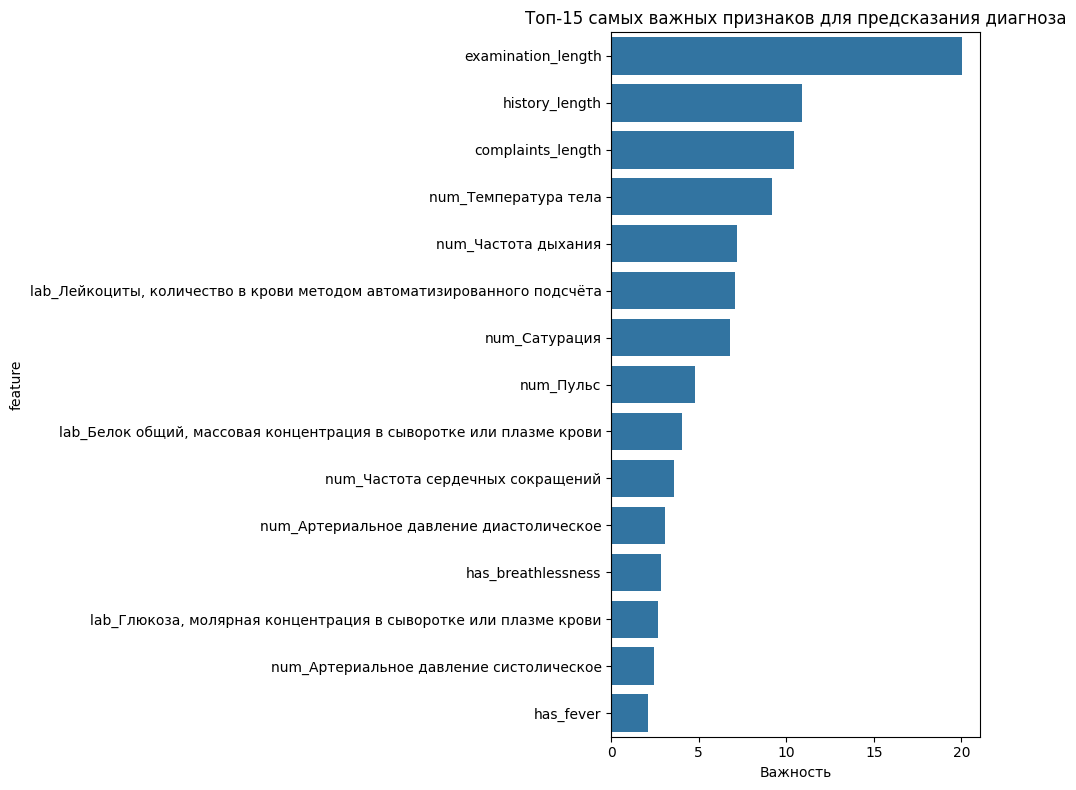

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Важность признаков
feature_importance = model.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("ТОП-15 САМЫХ ВАЖНЫХ ПРИЗНАКОВ")
print("="*50)
print(importance_df.head(15))

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков для предсказания диагноза')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [21]:
# Предсказания на тестовой выборке
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Метрики качества
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.3f}")
print(f"Размер тестовой выборки: {len(y_test)} примеров")

# Детальный отчет по классификации
print("\n" + "="*50)
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print("="*50)
print(classification_report(y_test, y_pred, target_names=top_diagnoses))

Точность модели: 0.781
Размер тестовой выборки: 196 примеров

ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ
                                                                                                   precision    recall  f1-score   support

                                     Другая уточненная хроническая обструктивная легочная болезнь       0.90      1.00      0.95        18
                                Злокачественное новообразование верхней доли, бронхов или легкого       0.75      0.43      0.55        14
   Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры       1.00      0.71      0.83        14
                                 Злокачественное новообразование нижней доли, бронхов или легкого       0.78      0.94      0.85        33
                                                                  COVID-19, вирус идентифицирован       0.88      0.88      0.88        16
                                                                   Дру


АНАЛИЗ УВЕРЕННОСТИ ПРЕДСКАЗАНИЙ
Средняя уверенность: 0.768
Медианная уверенность: 0.810


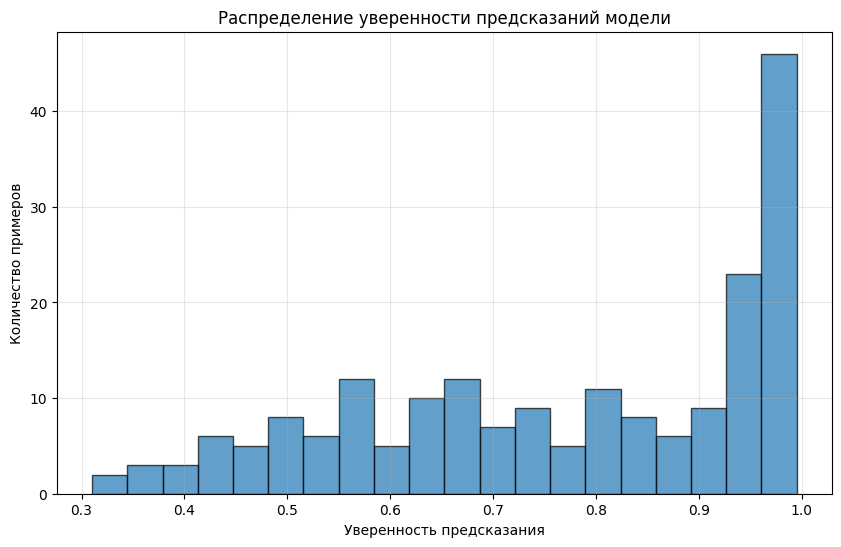


Точность по уровням уверенности:
confidence_bin
(0.0, 0.3]         NaN
(0.3, 0.5]    0.560000
(0.5, 0.7]    0.653061
(0.7, 0.9]    0.750000
(0.9, 1.0]    0.959459
Name: is_correct, dtype: float64


C:\Users\ckopn\AppData\Local\Temp\ipykernel_13532\49362678.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby('confidence_bin')['is_correct'].mean()


In [22]:
# Анализ уверенности модели
confidence_scores = np.max(y_pred_proba, axis=1)

print("\n" + "="*50)
print("АНАЛИЗ УВЕРЕННОСТИ ПРЕДСКАЗАНИЙ")
print("="*50)
print(f"Средняя уверенность: {confidence_scores.mean():.3f}")
print(f"Медианная уверенность: {np.median(confidence_scores):.3f}")

# Распределение уверенности
plt.figure(figsize=(10, 6))
plt.hist(confidence_scores, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Уверенность предсказания')
plt.ylabel('Количество примеров')
plt.title('Распределение уверенности предсказаний модели')
plt.grid(True, alpha=0.3)
plt.show()

# Точность в зависимости от уверенности
confidence_bins = pd.cut(confidence_scores, bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0])
accuracy_by_confidence = pd.DataFrame({
    'confidence_bin': confidence_bins,
    'is_correct': (y_pred.flatten() == y_test.values)
}).groupby('confidence_bin')['is_correct'].mean()

print("\nТочность по уровням уверенности:")
print(accuracy_by_confidence)

# Пример предсказаний

In [23]:
# Посмотрим на несколько конкретных примеров
test_examples = pd.DataFrame({
    'true_diagnosis': y_test,
    'predicted_diagnosis': y_pred.flatten(),
    'confidence': confidence_scores,
    'is_correct': (y_pred.flatten() == y_test.values)
})

print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("="*50)
print("Случаи с высокой уверенностью и правильным предсказанием:")
print(test_examples[test_examples['is_correct'] & (test_examples['confidence'] > 0.8)].head(10))

print("\nСлучаи с высокой уверенностью, но ошибкой:")
print(test_examples[~test_examples['is_correct'] & (test_examples['confidence'] > 0.8)].head(10))


ПРИМЕРЫ ПРЕДСКАЗАНИЙ
Случаи с высокой уверенностью и правильным предсказанием:
                                         true_diagnosis  \
83    Злокачественное новообразование нижней доли, б...   
732   Другая уточненная хроническая обструктивная ле...   
1218                    COVID-19, вирус идентифицирован   
1069  Другая уточненная хроническая обструктивная ле...   
428   Туберкулез легких, подтвержденный бактериоскоп...   
450   Туберкулез легких, подтвержденный бактериоскоп...   
755   Туберкулез легких, подтвержденный бактериоскоп...   
468   Туберкулез легких, подтвержденный бактериоскоп...   
91                       Другие бактериальные пневмонии   
339   Другая уточненная хроническая обструктивная ле...   

                                    predicted_diagnosis  confidence  \
83    Злокачественное новообразование нижней доли, б...    0.805126   
732   Другая уточненная хроническая обструктивная ле...    0.824265   
1218                    COVID-19, вирус идентифицирован  